### Import libraries

In [68]:
library(ggplot2)
library(scales)
library(gtable)
library(grid)
library(argparse)
library(ggforce)
options(repr.plot.width = 24, repr.plot.height = 6)

In [69]:
df = read.table("/home/lknq/GitHub/forge/notebook/analysis.txt", header = T, sep = "\t")
# head(df, 2)
df <- df[order(df$Start), ]
print(df)

     Chr    Start      End  Exome           Name Hom Het Total
1  chr14 88401213 88401213     17      c.1921A>G 530  73   603
2  chr14 88401219 88401219     17      c.1915C>T   0   1     1
3  chr14 88401222 88401222     17      c.1912G>A   0   1     1
4  chr14 88406259 88406259     16      c.1901T>C   0   4     4
5  chr14 88406315 88406315     16      c.1845T.A   0   1     1
6  chr14 88407757 88407757     15      c.1816A>T   0   1     1
7  chr14 88407795 88407795     15      c.1778G>C   0   1     1
8  chr14 88407875 88407875     15      c.1698A>T 530  72   602
9  chr14 88407888 88407888     15      c.1685T>C  35 217   252
10 chr14 88411947 88411947     14      c.1620A>G 530  73   603
11 chr14 88411951 88411951     14      c.1616T>C   0   1     1
12 chr14 88411975 88411975     14      c.1592G>A   0   6     6
13 chr14 88411994 88411994     14      c.1573G>A   0   9     9
14 chr14 88414211 88414211     13      c.1350C>T  35 214   249
15 chr14 88416225 88416225     12      c.1302C>T   2  4

     Chr    Start      End  Exome           Name Hom Het Total    pos
1  chr14 88401213 88401213     17      c.1921A>G 530  73   603  97051
2  chr14 88401219 88401219     17      c.1915C>T   0   1     1  97057
3  chr14 88401222 88401222     17      c.1912G>A   0   1     1  97060
4  chr14 88406259 88406259     16      c.1901T>C   0   4     4 102097
5  chr14 88406315 88406315     16      c.1845T.A   0   1     1 102153
6  chr14 88407757 88407757     15      c.1816A>T   0   1     1 103595
7  chr14 88407795 88407795     15      c.1778G>C   0   1     1 103633
8  chr14 88407875 88407875     15      c.1698A>T 530  72   602 103713
9  chr14 88407888 88407888     15      c.1685T>C  35 217   252 103726
10 chr14 88411947 88411947     14      c.1620A>G 530  73   603 107785
11 chr14 88411951 88411951     14      c.1616T>C   0   1     1 107789
12 chr14 88411975 88411975     14      c.1592G>A   0   6     6 107813
13 chr14 88411994 88411994     14      c.1573G>A   0   9     9 107832
14 chr14 88414211 88

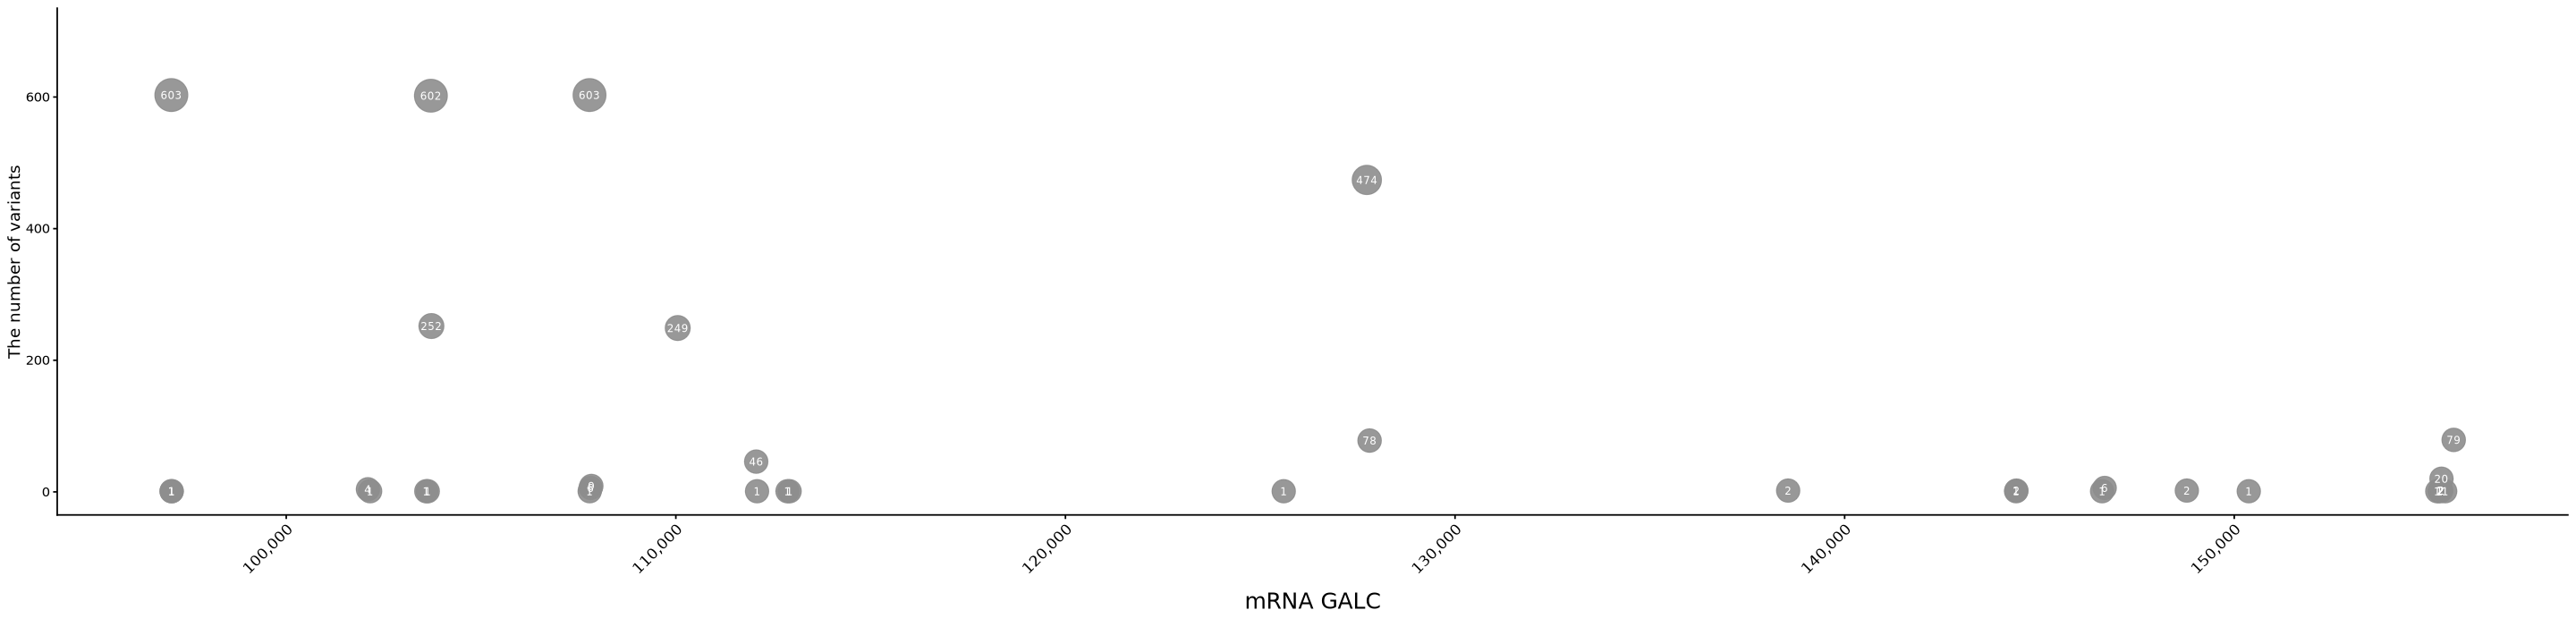

In [70]:
maxPOS=88460009
minPOS=88401213


gene_start = 88304163

df$pos = df$Start - gene_start + 1

print(df)

df$point_size <- scales::rescale(
    46 * (df$Total^2) + 2,
    to = c(7, 10)
)
main_chart = ggplot(
    data=df, 
    aes(x=pos, y=Total)
) + 
ylab(
    "The number of variants"
) + 
xlab(
    "mRNA GALC"
) + 
scale_x_continuous(
    labels=comma, 
    breaks = scales::pretty_breaks(n=5), 
    limits = c(min(df$pos), max(df$pos))
) + 
scale_y_continuous(
    limits=c(0, 700)
) + 
geom_point(
    pch=21, 
    color="#8d8d8d", 
    fill="#8d8d8d", 
    size = df$point_size,
    alpha = 0.9,
) + 
scale_size_identity(

) + 
geom_text(
    aes(label = round(Total, 1)),
    color = "white",
    size = 2.5
) + 
theme_classic(

) + 
theme(
    # axis.line.y = element_blank(),
    # axis.text.y = element_blank(),
    # axis.ticks.y = element_blank(),
    # axis.title.y = element_blank(),
    
    axis.text.x = element_text(
        size = 10,
        angle = 45, 
        hjust = 1
    ),
    axis.title.x = element_text(
        size = 15,
        margin = margin(t = 15, b = 15)
    ),
)

# chart = chart + geom_text(
#     aes(label = Name),
#     vjust = 0,
#     hjust = -0.3,
#     size = 4,
#     angle = 90
# )

main_chart


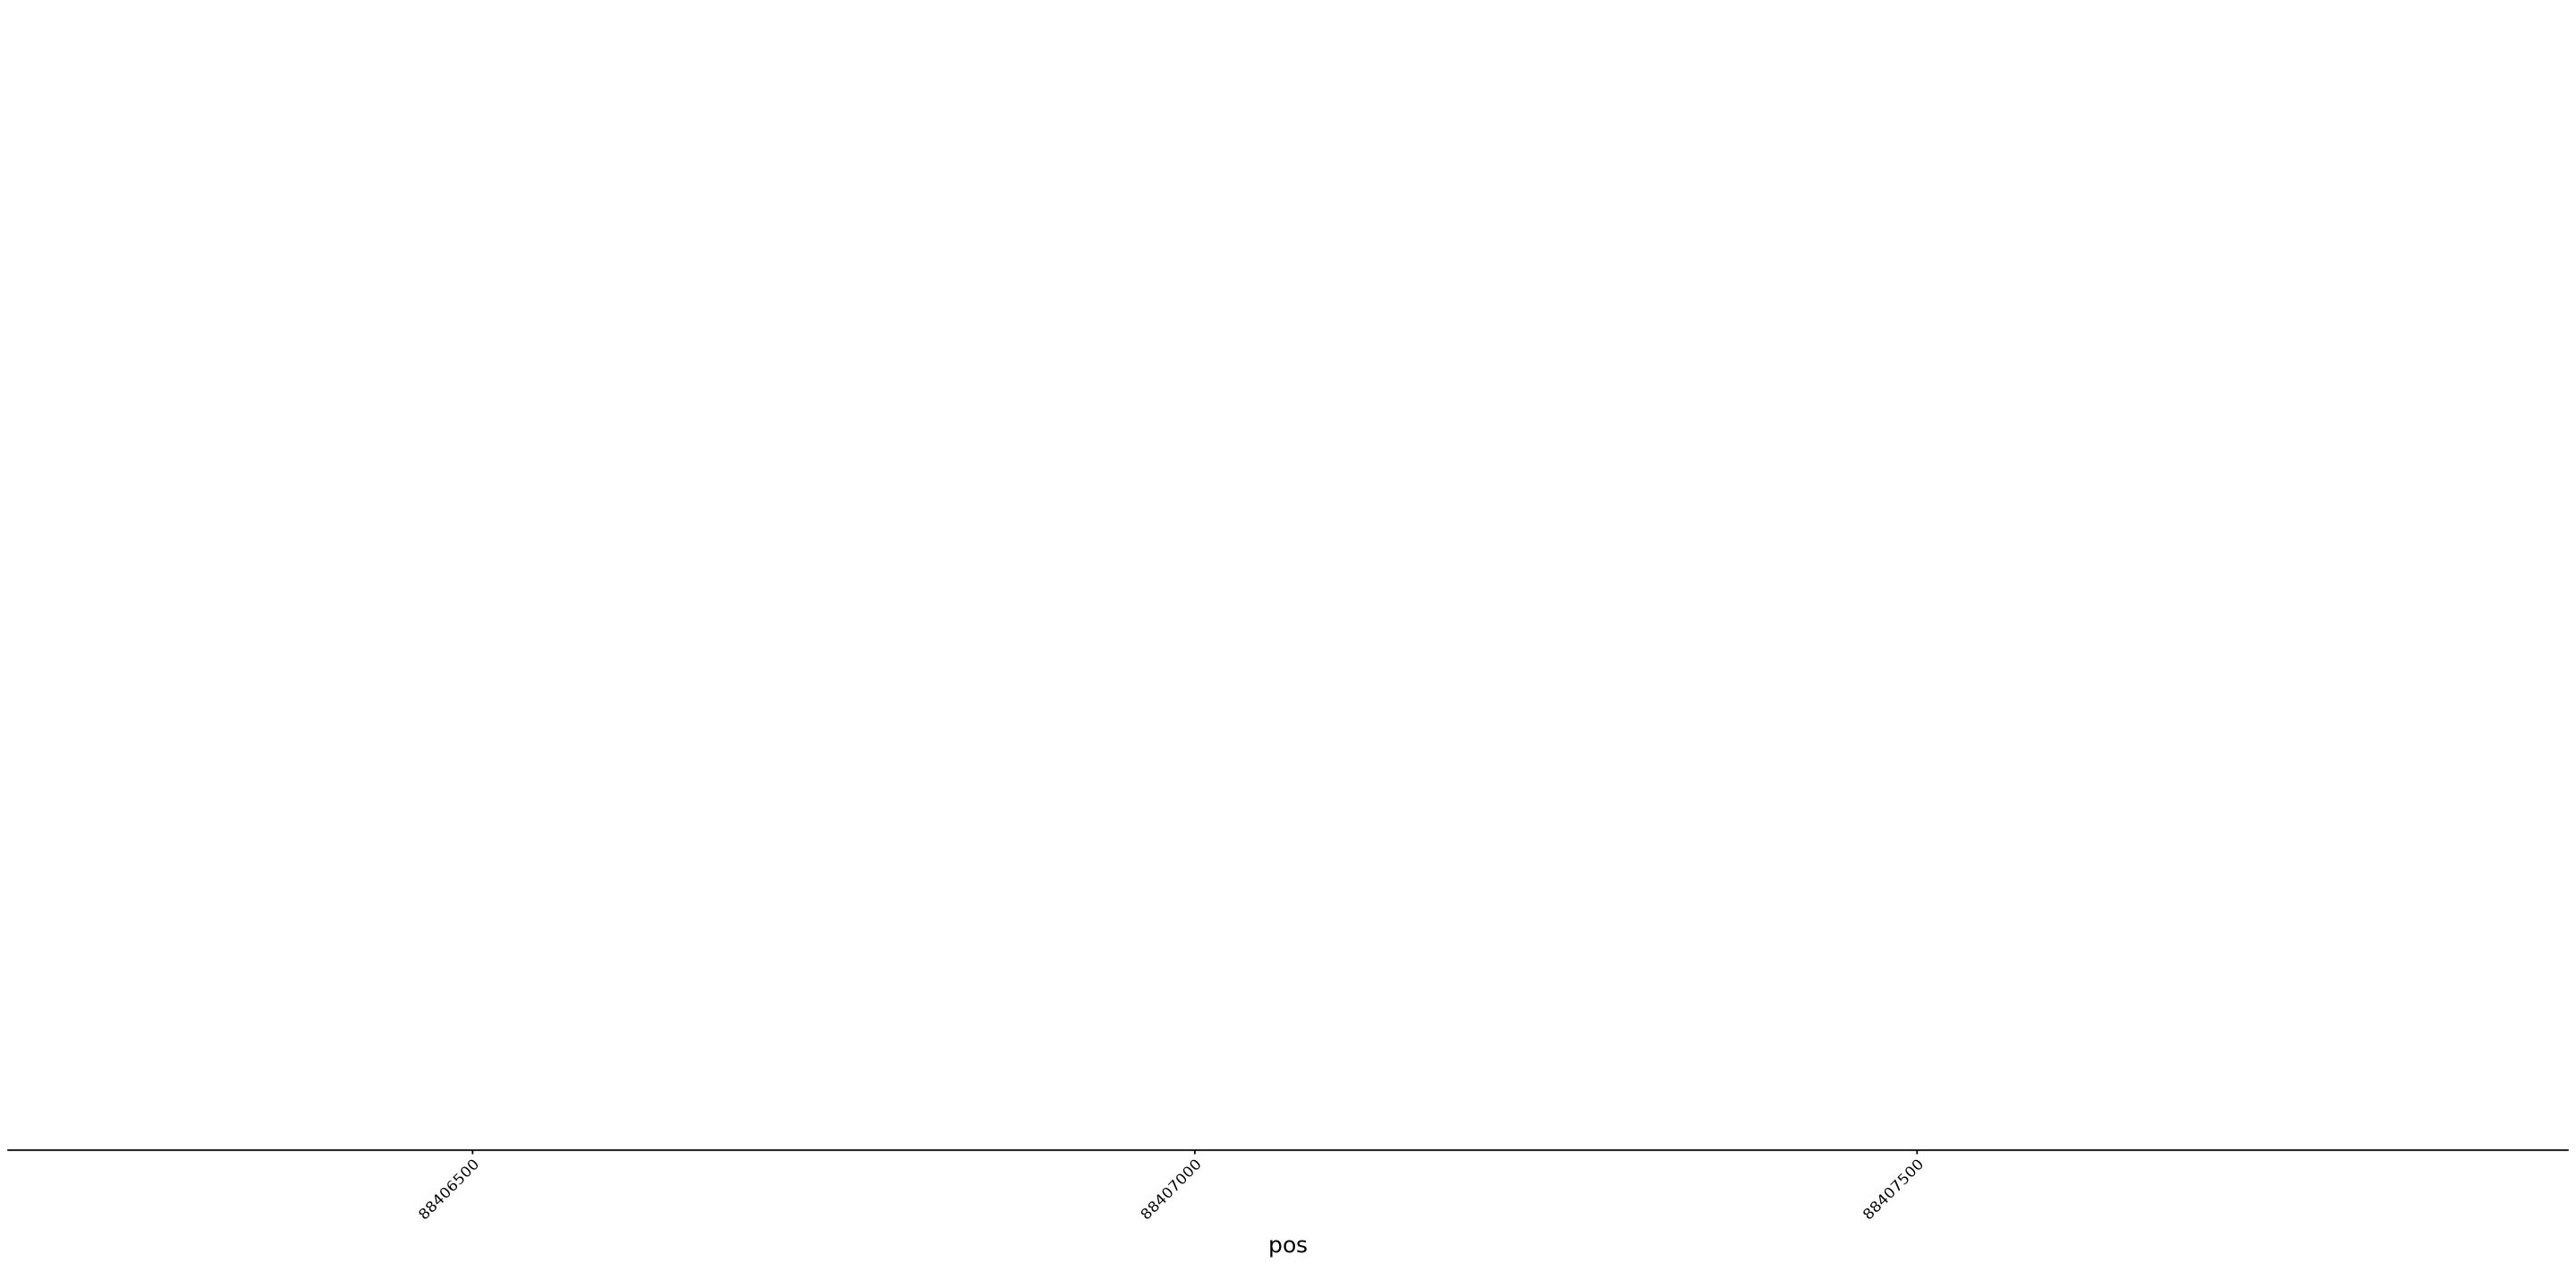

In [49]:
chart_2 = ggplot(
    data=df, 
    aes(x = pos, y = Total)
    ) + coord_cartesian(
        xlim = c(88406259, 88407870), 
        ylim = c(0, 5)
    ) +
    geom_point(
        pch=21, 
        color="#8d8d8d", 
        fill="#8d8d8d", 
        size = 5,
        alpha = 0.9,
    ) + 
    scale_size_identity(       
    ) + 
    theme_classic(

    ) +
    theme(
        axis.line.y = element_blank(),
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank(),
        axis.title.y = element_blank(),
        
        axis.text.x = element_text(
            size = 10,
            angle = 45, 
            hjust = 1
        ),
        axis.title.x = element_text(
            size = 15,
            margin = margin(t = 15, b = 15)
        ),
    )

chart_2

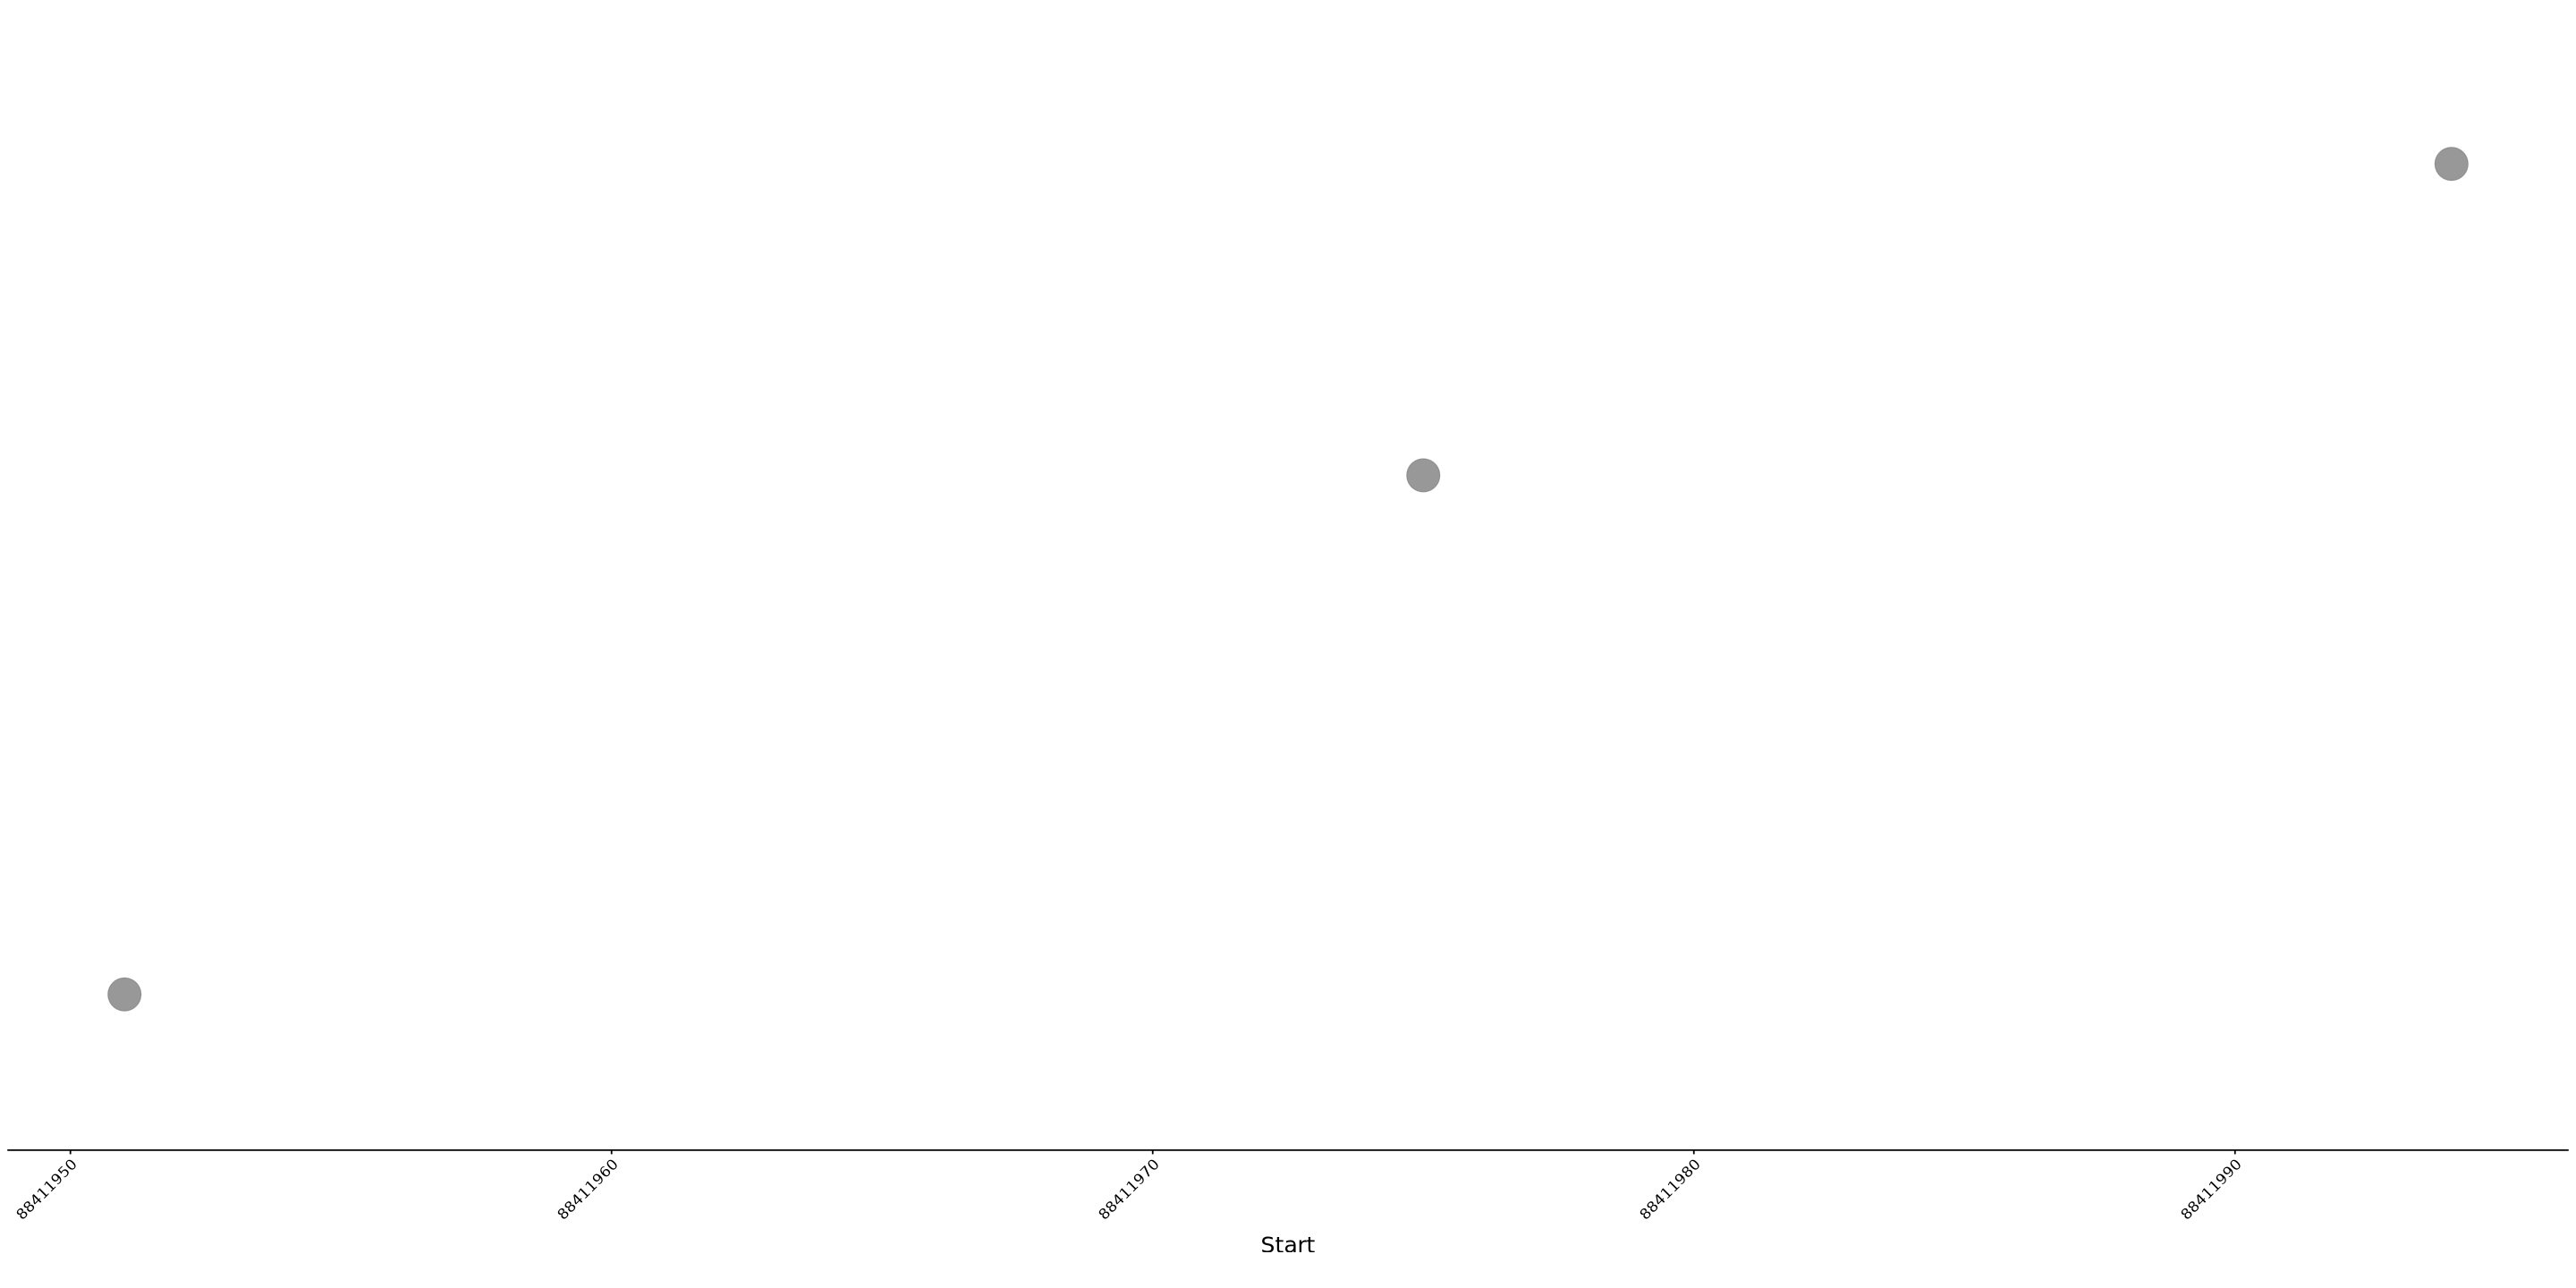

In [50]:
chart_3 = ggplot(
    data=df, 
    aes(x = Start, y = Total)
    ) + coord_cartesian(
        xlim = c(88411951, 88411994), 
        ylim = c(0, 10)
    ) +
    geom_point(
        pch=21, 
        color="#8d8d8d", 
        fill="#8d8d8d", 
        size = df$point_size,
        alpha = 0.9,
    ) + 
    scale_size_identity(       
    ) + 
    theme_classic(

    ) +
    theme(
        axis.line.y = element_blank(),
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank(),
        axis.title.y = element_blank(),
        
        axis.text.x = element_text(
            size = 10,
            angle = 45, 
            hjust = 1
        ),
        axis.title.x = element_text(
            size = 15,
            margin = margin(t = 15, b = 15)
        ),
    )

chart_3

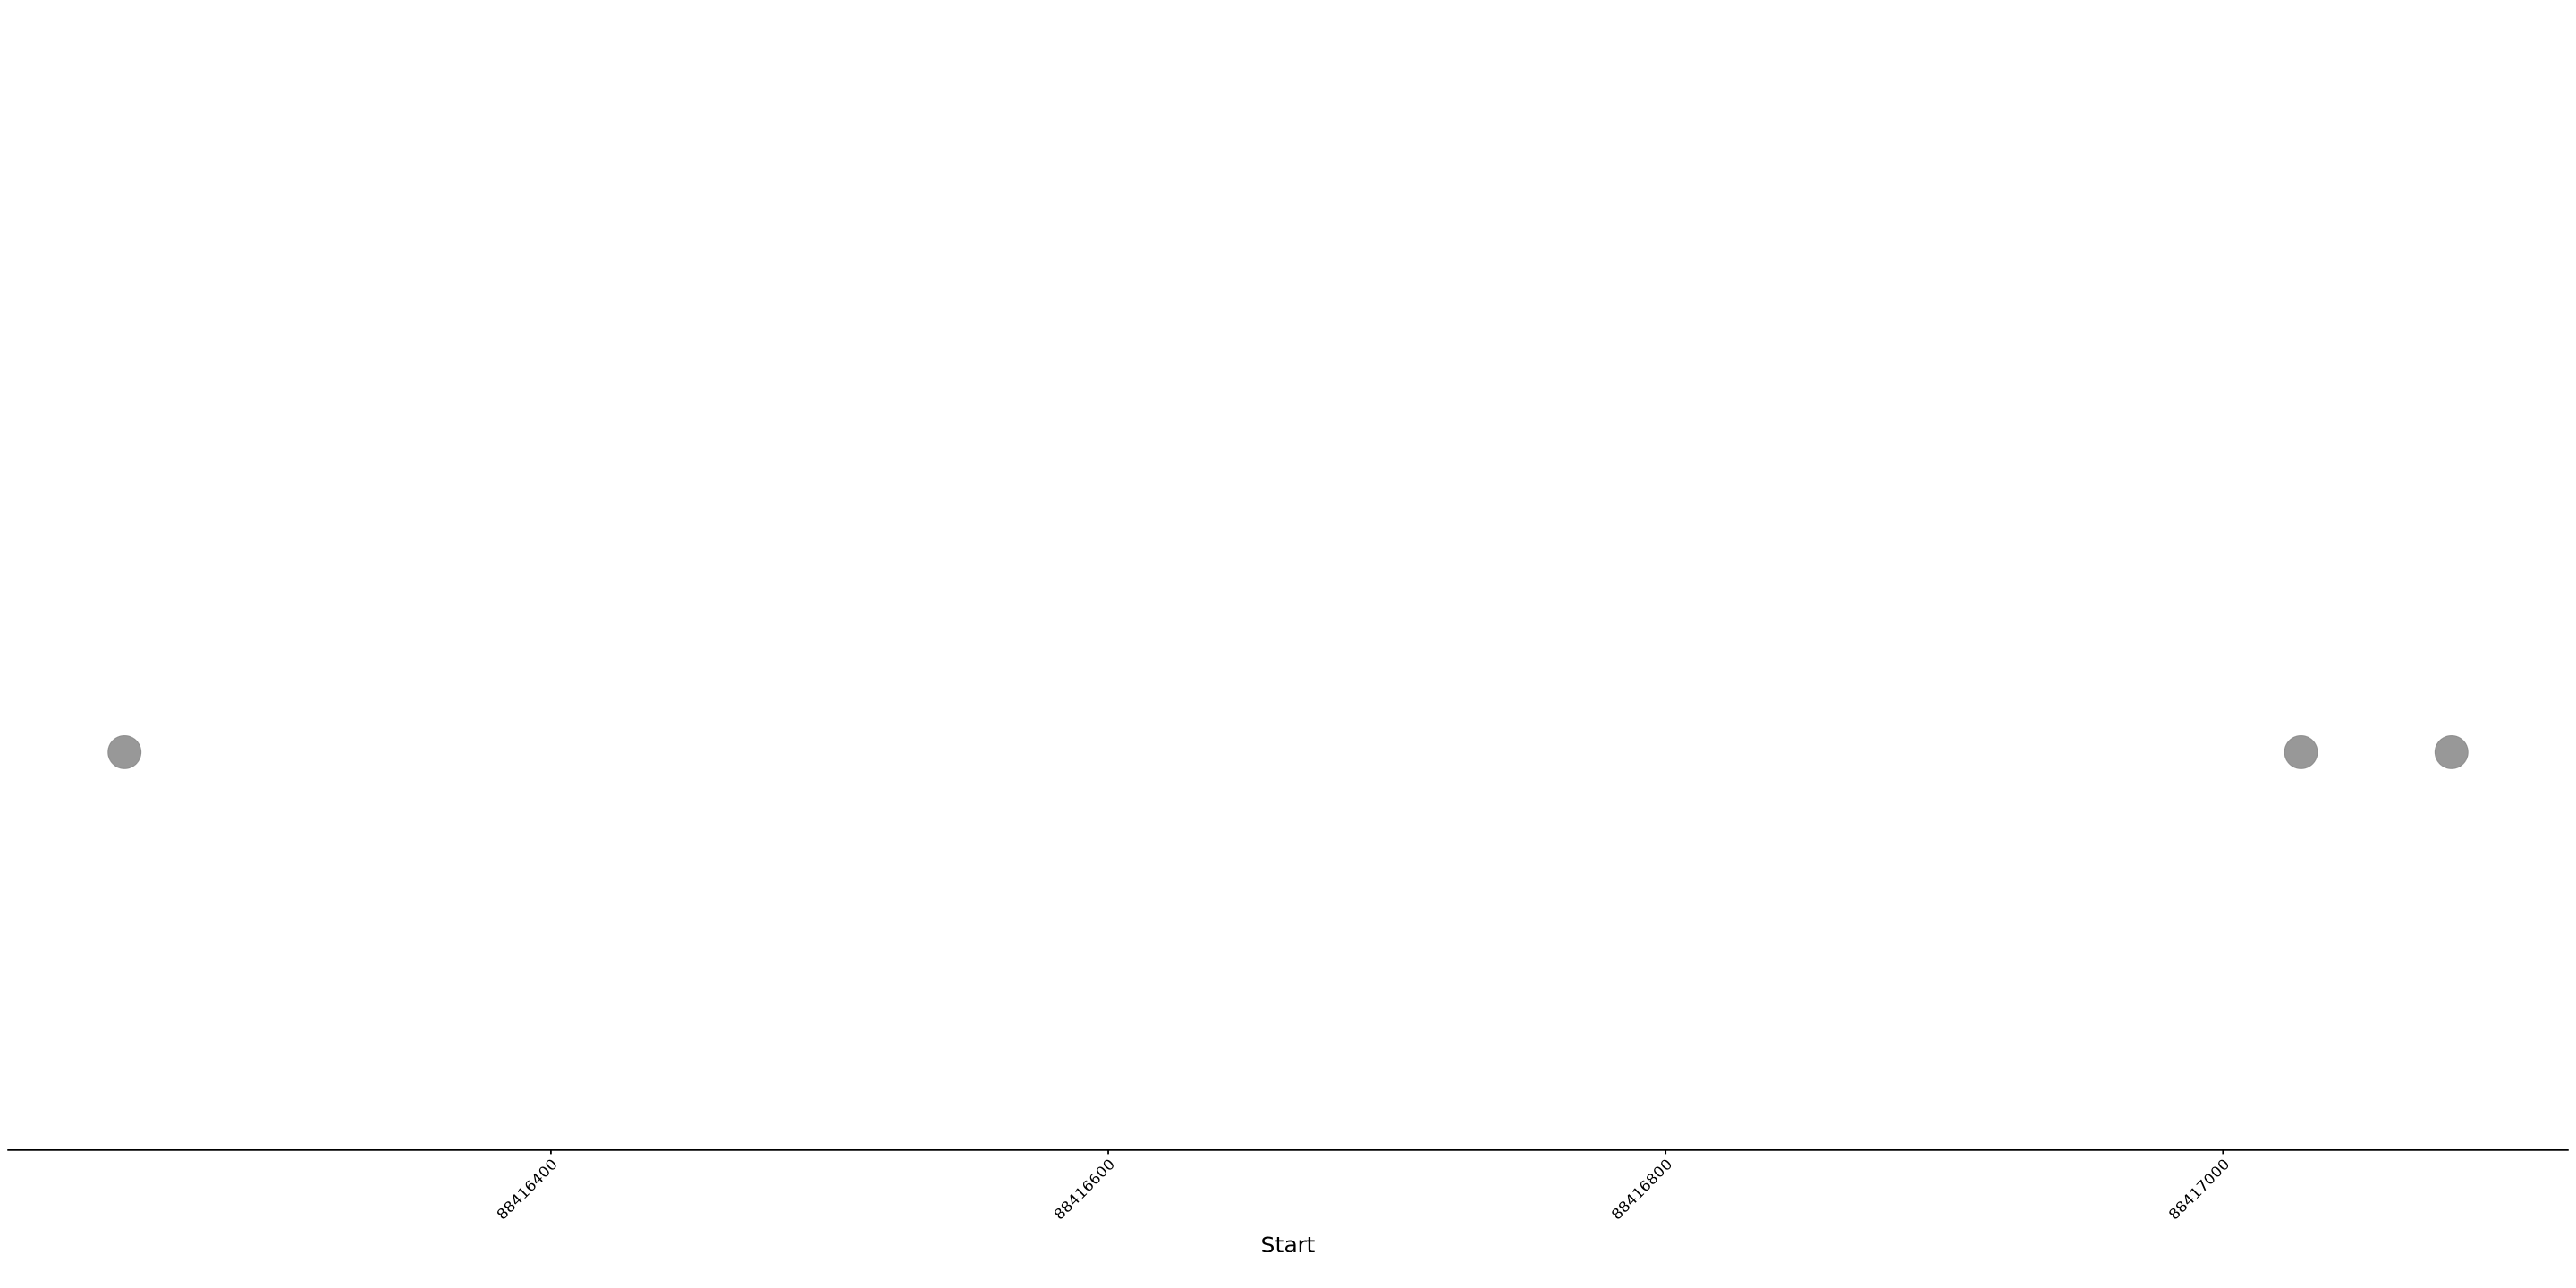

In [51]:
chart_4 = ggplot(
    data=df, 
    aes(x = Start, y = Total)
    ) + coord_cartesian(
        xlim = c(88416247, 88417082), 
        ylim = c(0, 3)
    ) +
    geom_point(
        pch=21, 
        color="#8d8d8d", 
        fill="#8d8d8d", 
        size = df$point_size,
        alpha = 0.9,
    ) + 
    scale_size_identity(       
    ) + 
    theme_classic(

    ) +
    theme(
        axis.line.y = element_blank(),
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank(),
        axis.title.y = element_blank(),
        
        axis.text.x = element_text(
            size = 10,
            angle = 45, 
            hjust = 1
        ),
        axis.title.x = element_text(
            size = 15,
            margin = margin(t = 15, b = 15)
        ),
    )

chart_4

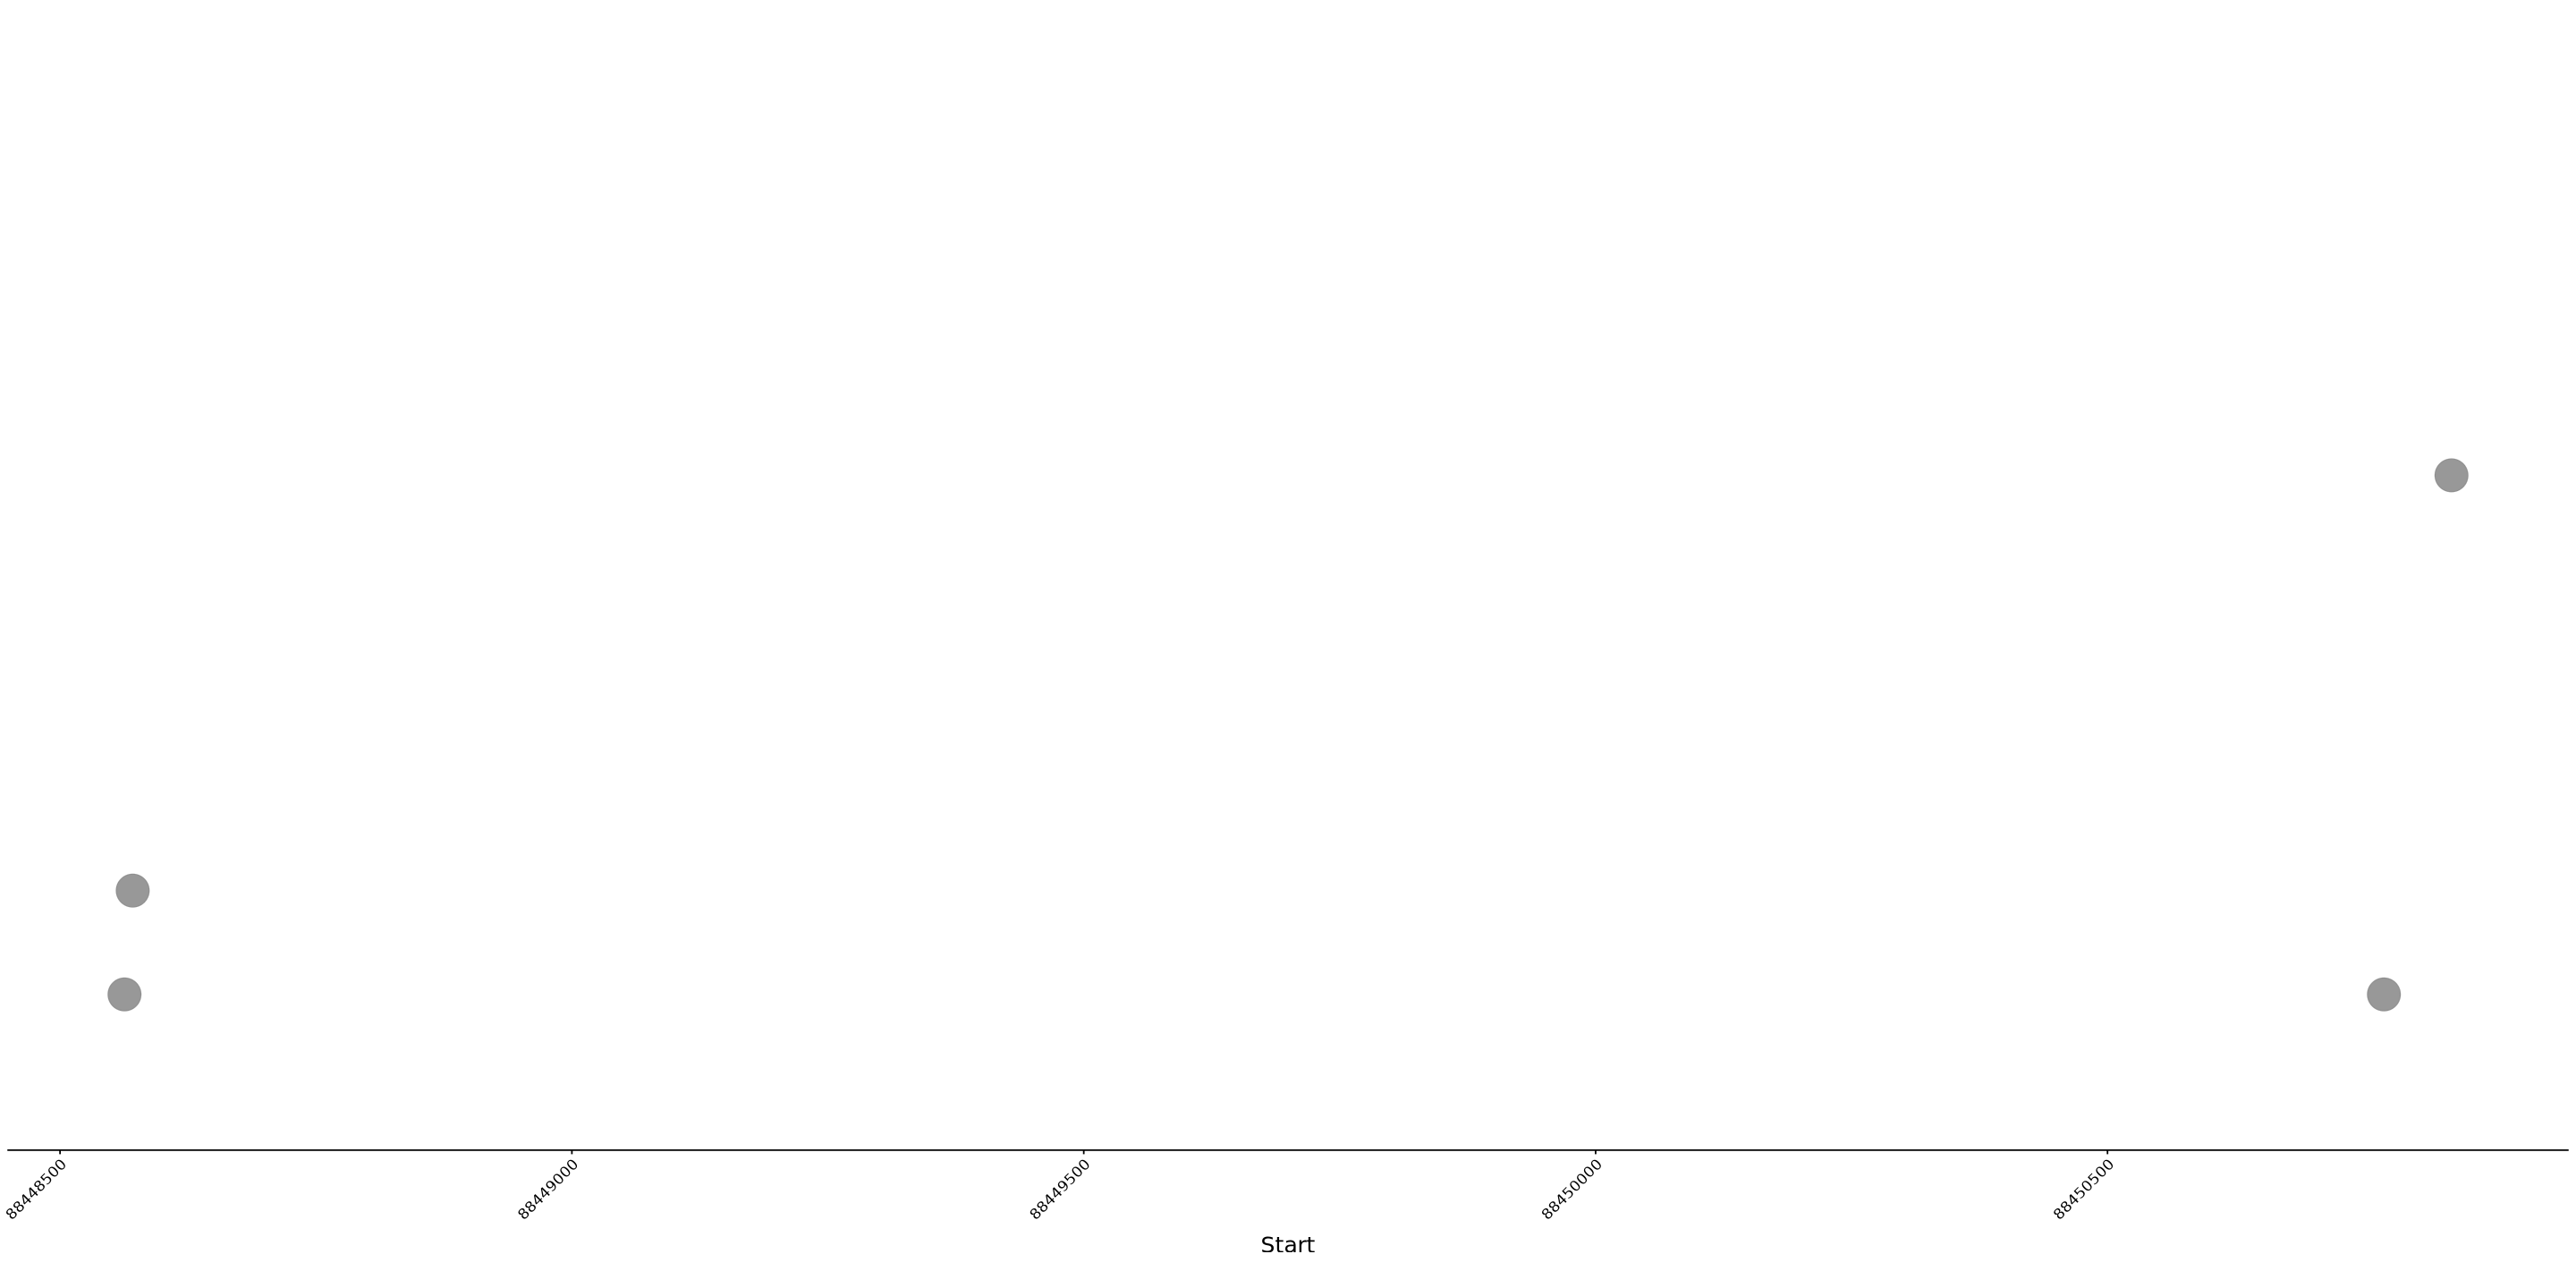

In [52]:
chart_5 = ggplot(
    data=df, 
    aes(x = Start, y = Total)
    ) + coord_cartesian(
        xlim = c(88448563, 88450836), 
        ylim = c(0, 10)
    ) +
    geom_point(
        pch=21, 
        color="#8d8d8d", 
        fill="#8d8d8d", 
        size = 10,
        alpha = 0.9,
    ) + 
    scale_size_identity(       
    ) + 
    theme_classic(

    ) +
    theme(
        axis.line.y = element_blank(),
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank(),
        axis.title.y = element_blank(),
        
        axis.text.x = element_text(
            size = 10,
            angle = 45, 
            hjust = 1
        ),
        axis.title.x = element_text(
            size = 15,
            margin = margin(t = 15, b = 15)
        ),
    )

chart_5

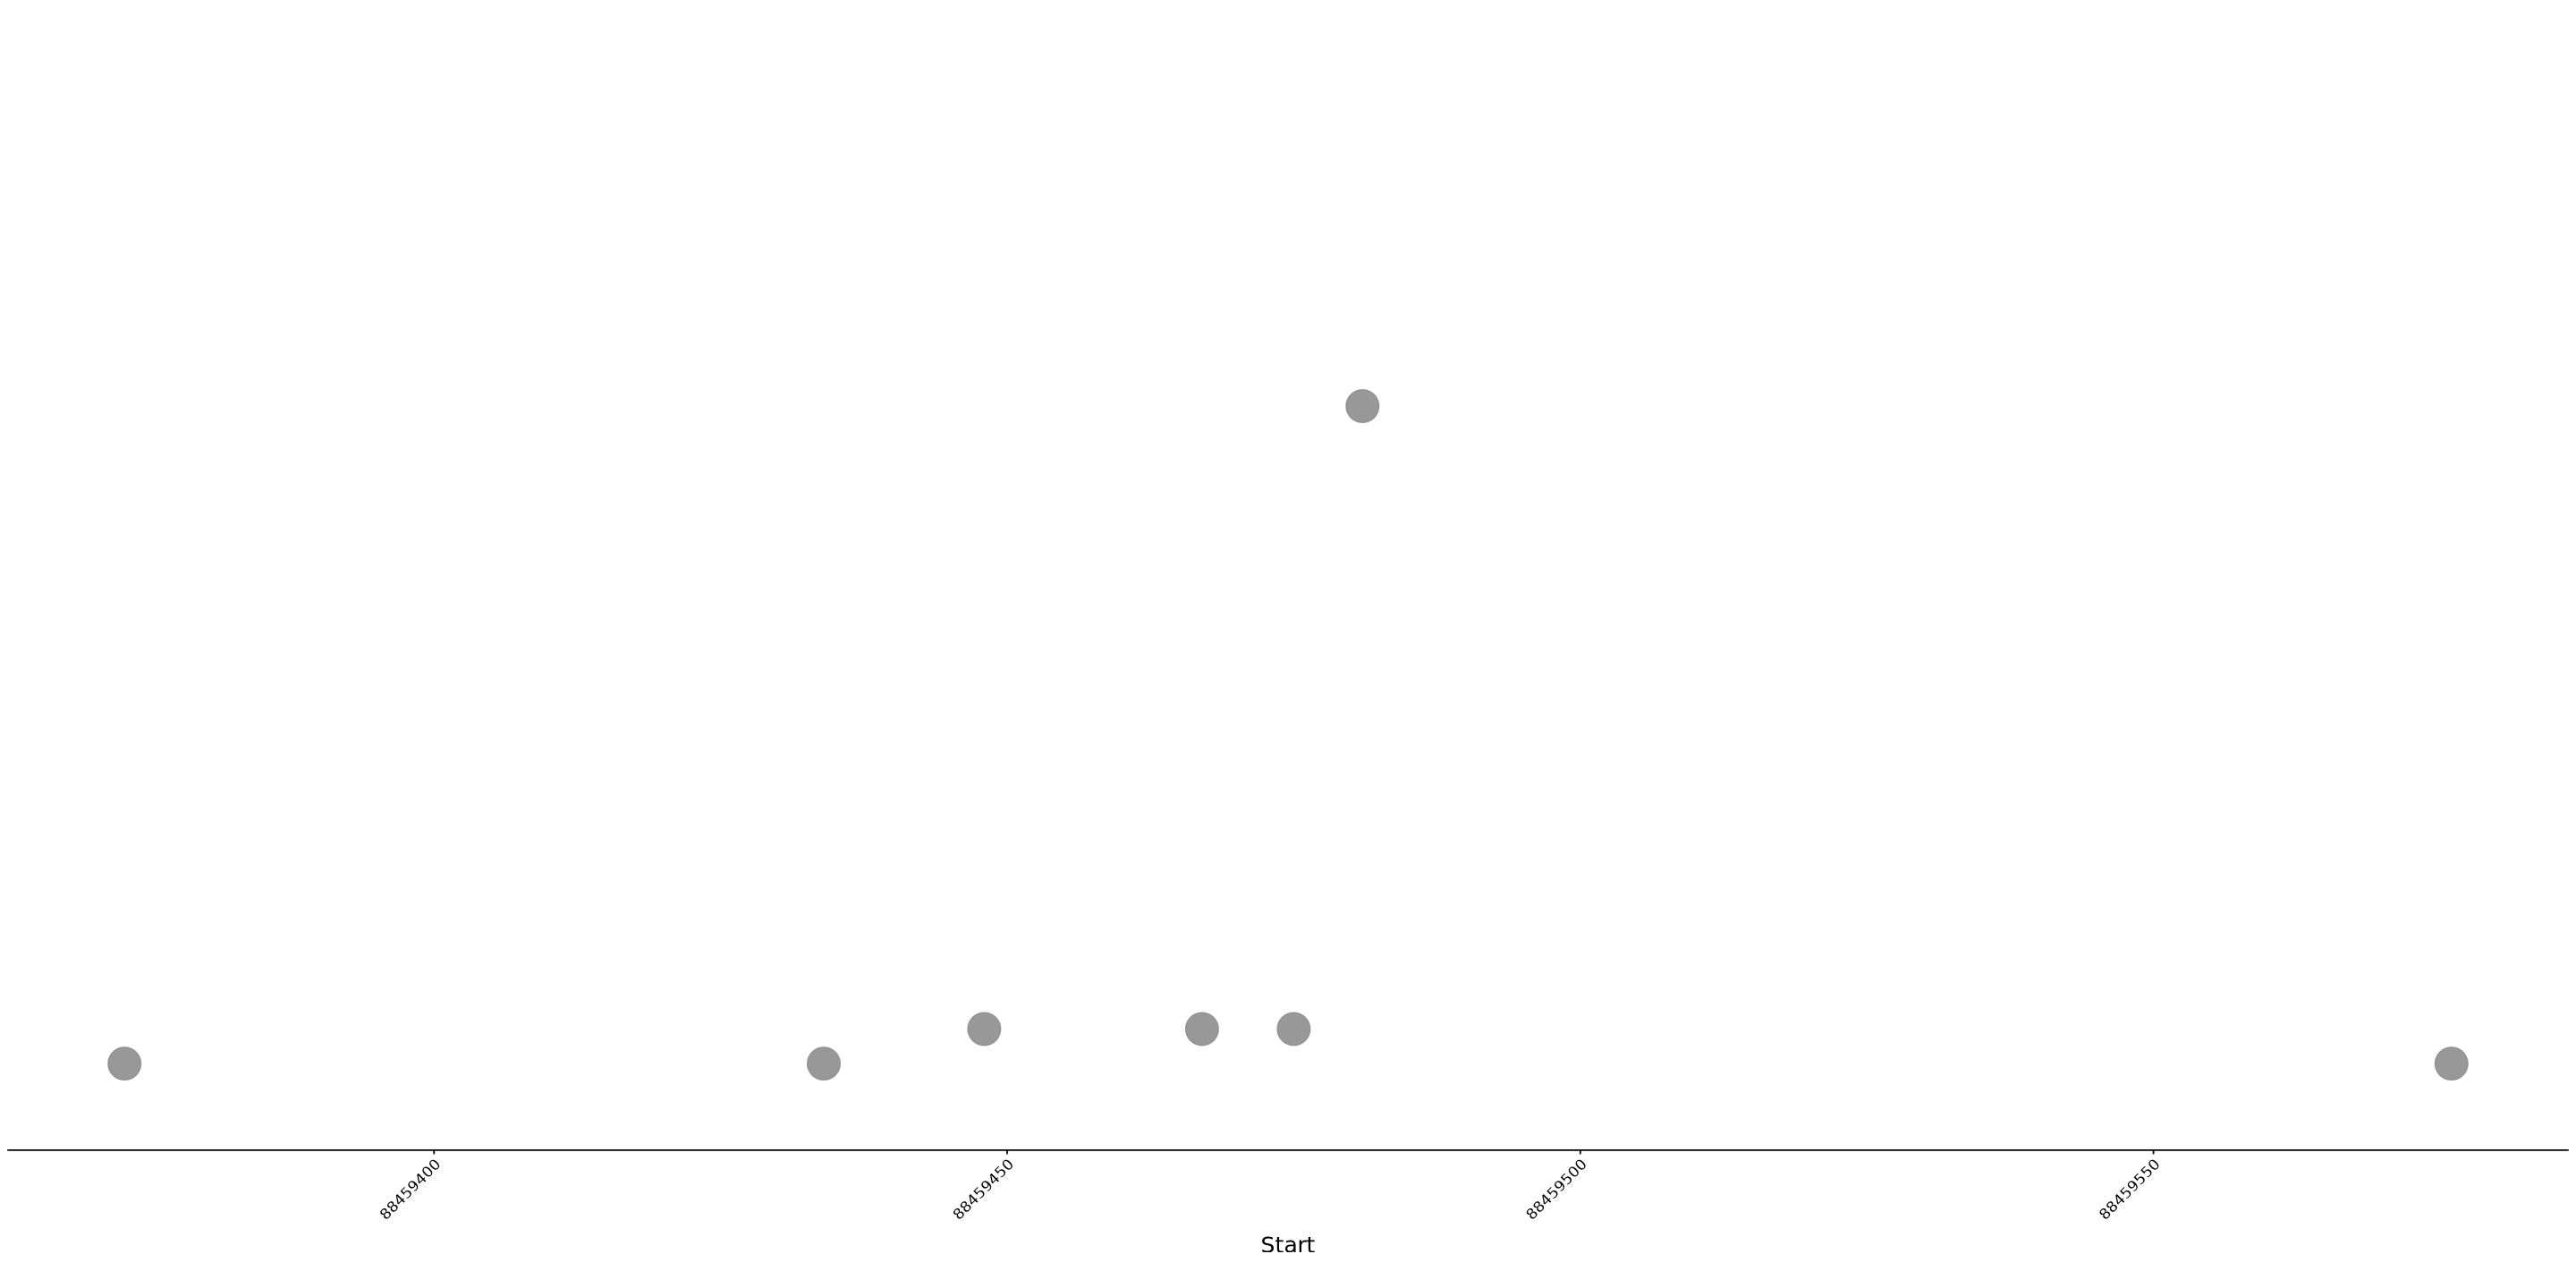

In [53]:
chart_6 = ggplot(
    data=df, 
    aes(x = Start, y = Total)
    ) + coord_cartesian(
        xlim = c(88459373, 88459576), 
        ylim = c(0, 30)
    ) +
    geom_point(
        pch=21, 
        color="#8d8d8d", 
        fill="#8d8d8d", 
        size = df$point_size,
        alpha = 0.9,
    ) + 
    scale_size_identity(       
    ) + 
    theme_classic(

    ) +
    theme(
        axis.line.y = element_blank(),
        axis.text.y = element_blank(),
        axis.ticks.y = element_blank(),
        axis.title.y = element_blank(),
        
        axis.text.x = element_text(
            size = 10,
            angle = 45, 
            hjust = 1
        ),
        axis.title.x = element_text(
            size = 15,
            margin = margin(t = 15, b = 15)
        ),
    )

chart_6

In [71]:
ggsave(
    plot = main_chart, 
    file=file.path("/home/lknq/GitHub/forge/notebook", paste0("Krabe.pdf")), 
    width=24, 
    height=12
)

In [56]:
print(warnings())